# Precious Metals and Stock Rotation

Test gold/silver momentum and rotation between stocks, gold, silver, bonds, and cash.

## Code Steps

1. Load `extended_close_prices.csv` from notebook 04.
2. Test standalone GLD and SLV momentum strategies.
3. Test rotation across `SPY`, `QQQ`, `GLD`, `SLV`, and `TLT`.
4. Test a simple gold/silver ratio rule.
5. Score everything by Sharpe, return, volatility, drawdown, and turnover.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.research.backtest import backtest_weights, format_percent_table
from src.research.strategies import buy_and_hold_weights, long_cash_momentum_weights, top_n_momentum_weights, empty_weights

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLOSE_PATH = PROCESSED_DIR / "extended_close_prices.csv"
DAILY_OUTPUT_PATH = PROCESSED_DIR / "metals_rotation_daily.csv"
RESULTS_OUTPUT_PATH = PROCESSED_DIR / "metals_rotation_results.csv"

In [2]:
close = pd.read_csv(CLOSE_PATH, index_col="Date", parse_dates=True)
assets = ["SPY", "QQQ", "GLD", "SLV", "TLT"]
close = close[assets].dropna()

close.tail()

,SPY,QQQ,GLD,SLV,TLT
Date,,,,,
2026-06-29,741.000000,724.080017,368.579987,52.680000,87.128204
2026-06-30,746.770020,736.400024,368.380005,53.470001,86.101997
2026-07-01,745.760010,725.169983,370.600006,53.580002,85.519997
2026-07-02,744.780029,712.599976,378.130005,55.020000,85.510002
2026-07-06,751.669983,723.369995,381.930115,56.174999,85.349899


In [3]:
def gold_silver_ratio_weights(window: int = 60, z_entry: float = 1.0):
    weights = empty_weights(close)
    ratio = close["GLD"] / close["SLV"]
    ratio_mean = ratio.rolling(window).mean()
    ratio_std = ratio.rolling(window).std()
    z_score = (ratio - ratio_mean) / ratio_std

    # If ratio is high, silver is cheap relative to gold: hold SLV.
    # If ratio is low, gold is cheap relative to silver: hold GLD.
    weights.loc[z_score > z_entry, "SLV"] = 1.0
    weights.loc[z_score < -z_entry, "GLD"] = 1.0
    return weights


strategy_weights = {
    "buy_hold_GLD": buy_and_hold_weights(close, "GLD"),
    "buy_hold_SLV": buy_and_hold_weights(close, "SLV"),
}

for window in [20, 60, 120]:
    strategy_weights[f"GLD_momentum_{window}d_long_cash"] = long_cash_momentum_weights(close, "GLD", window)
    strategy_weights[f"SLV_momentum_{window}d_long_cash"] = long_cash_momentum_weights(close, "SLV", window)
    strategy_weights[f"stock_metals_bonds_rotation_{window}d"] = top_n_momentum_weights(close, assets, window, top_n=1)
    strategy_weights[f"stock_metals_bonds_top2_{window}d"] = top_n_momentum_weights(close, assets, window, top_n=2)

strategy_weights["gold_silver_ratio_60d"] = gold_silver_ratio_weights(60, 1.0)

len(strategy_weights)

15

In [4]:
daily_frames = []
metric_rows = []

for name, weights in strategy_weights.items():
    daily, metrics = backtest_weights(close, weights, name=name, transaction_cost_bps=2.0)
    daily_frames.append(daily)
    metric_rows.append(metrics)

metals_daily = pd.concat(daily_frames, ignore_index=True)
metals_results = pd.DataFrame(metric_rows).sort_values("sharpe", ascending=False)

metals_results

,strategy,rows,total_return,annual_return,annual_volatility,sharpe,max_drawdown,calmar,positive_day_rate,avg_exposure,annual_turnover,total_transaction_cost
6,GLD_momentum_60d_long_cash,2892,2.164348,0.105588,0.134205,0.815447,-0.185402,0.569508,0.335754,0.613762,9.236515,0.0212
10,GLD_momentum_120d_long_cash,2892,2.064614,0.102507,0.140351,0.765925,-0.212136,0.483213,0.374827,0.685685,6.448133,0.0148
0,buy_hold_GLD,2892,2.347915,0.111034,0.160444,0.736870,-0.262109,0.423616,0.530429,1.000000,0.000000,0.0000
13,stock_metals_bonds_top2_120d,2892,2.136364,0.104732,0.199497,0.600769,-0.352002,0.297533,0.500346,0.905256,26.489627,0.0608
1,buy_hold_SLV,2892,2.717737,0.121224,0.311317,0.526778,-0.509659,0.237853,0.512448,1.000000,0.000000,0.0000
9,stock_metals_bonds_top2_60d,2892,1.529494,0.084224,0.189639,0.522913,-0.405825,0.207538,0.501729,0.928423,41.477178,0.0952
5,stock_metals_bonds_top2_20d,2892,1.441206,0.080873,0.186329,0.512062,-0.287992,0.280817,0.485823,0.913209,74.066390,0.1700
4,stock_metals_bonds_rotation_20d,2892,1.888047,0.096821,0.239934,0.508723,-0.463916,0.208703,0.478216,0.913209,93.846473,0.2154
12,stock_metals_bonds_rotation_120d,2892,1.767616,0.092757,0.268530,0.468614,-0.426579,0.217445,0.492047,0.905256,33.373444,0.0766
11,SLV_momentum_120d_long_cash,2892,1.506239,0.083352,0.262721,0.440101,-0.456188,0.182714,0.292877,0.559474,11.327801,0.0260


In [5]:
percent_cols = [
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "calmar",
    "avg_exposure",
    "annual_turnover",
    "total_transaction_cost",
    "positive_day_rate",
]

format_percent_table(metals_results, percent_cols)[[
    "strategy",
    "sharpe",
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "avg_exposure",
    "annual_turnover",
]]

,strategy,sharpe,total_return,annual_return,annual_volatility,max_drawdown,avg_exposure,annual_turnover
6,GLD_momentum_60d_long_cash,0.815447,216.43%,10.56%,13.42%,-18.54%,61.38%,923.65%
10,GLD_momentum_120d_long_cash,0.765925,206.46%,10.25%,14.04%,-21.21%,68.57%,644.81%
0,buy_hold_GLD,0.736870,234.79%,11.10%,16.04%,-26.21%,100.00%,0.00%
13,stock_metals_bonds_top2_120d,0.600769,213.64%,10.47%,19.95%,-35.20%,90.53%,2648.96%
1,buy_hold_SLV,0.526778,271.77%,12.12%,31.13%,-50.97%,100.00%,0.00%
9,stock_metals_bonds_top2_60d,0.522913,152.95%,8.42%,18.96%,-40.58%,92.84%,4147.72%
5,stock_metals_bonds_top2_20d,0.512062,144.12%,8.09%,18.63%,-28.80%,91.32%,7406.64%
4,stock_metals_bonds_rotation_20d,0.508723,188.80%,9.68%,23.99%,-46.39%,91.32%,9384.65%
12,stock_metals_bonds_rotation_120d,0.468614,176.76%,9.28%,26.85%,-42.66%,90.53%,3337.34%
11,SLV_momentum_120d_long_cash,0.440101,150.62%,8.34%,26.27%,-45.62%,55.95%,1132.78%


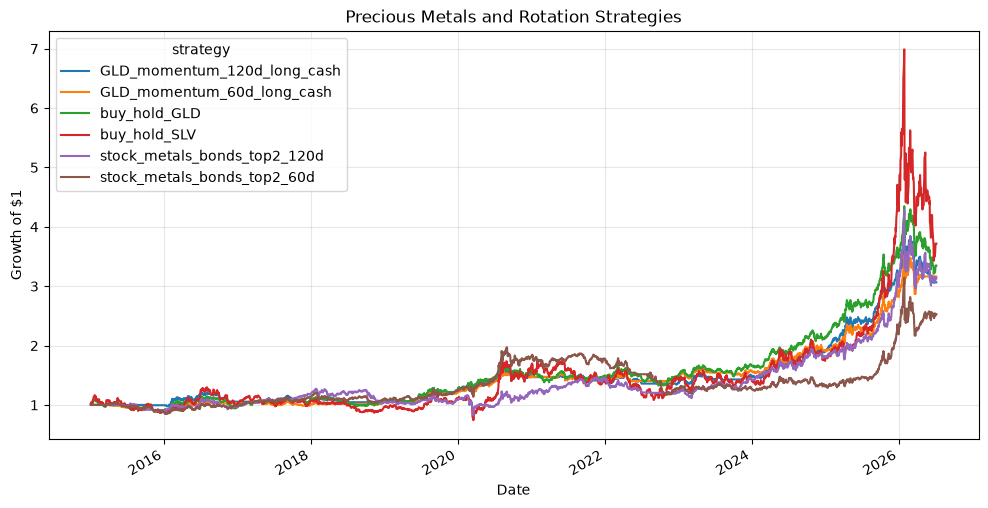

In [6]:
top_strategies = metals_results.head(6)["strategy"].tolist()
plot_frame = metals_daily[metals_daily["strategy"].isin(top_strategies)]
plot_frame = plot_frame.pivot(index="Date", columns="strategy", values="equity_curve")

ax = plot_frame.plot(figsize=(12, 6))
ax.set_title("Precious Metals and Rotation Strategies")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
plt.show()

In [7]:
metals_daily.to_csv(DAILY_OUTPUT_PATH, index=False)
metals_results.to_csv(RESULTS_OUTPUT_PATH, index=False)

DAILY_OUTPUT_PATH, RESULTS_OUTPUT_PATH

(WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/metals_rotation_daily.csv'),
 WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/metals_rotation_results.csv'))